In [1]:
import pandas as pd
import seaborn as sns
import numpy as np
import os
import matplotlib.pyplot as plt
import openml
import yaml
import tqdm
from pymoo.indicators.hv import HV
import warnings
from sklearn.metrics import r2_score
from scipy.stats import spearmanr

from utility import compute_min_max, get_pareto_front, compute_ranks, compute_extremes, get_all_dataframes, get_group_task_ids
from colors import COLORS

In [2]:
if not os.path.exists("./data/processed_data"):
    os.makedirs("./data/processed_data")

if os.path.exists("./data/processed_data/min_max.yaml"):
    with open("./data/processed_data/min_max.yaml", "r") as f:
        min_max_values = yaml.safe_load(f)
else:
    all_df = get_all_dataframes()
    min_max_values = compute_min_max(all_df)
    with open("./data/processed_data/min_max.yaml", "w") as f:
        yaml.dump(min_max_values, f)
    del all_df
assert len(min_max_values) == 104

In [5]:
METRIC_MAP = {
    "inference_time": "Inference Time",
    "energy_consumption": "Energy Consumption",
}

/home/janek/miniconda3/envs/raaml/lib/python3.11/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


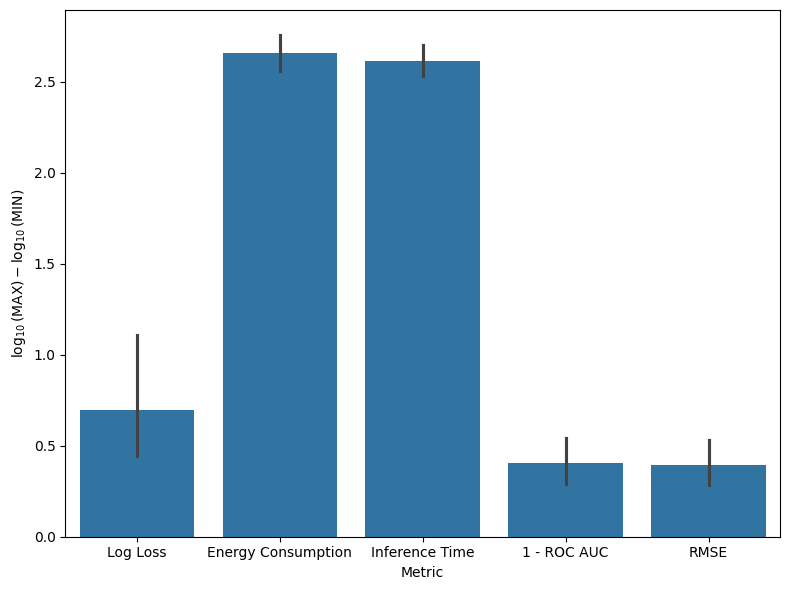

In [6]:
metrics_ranges = []
for task_id in min_max_values:
    min, max = min_max_values[task_id]
    for metric in min:
        metrics_ranges.append({
            "Metric" : METRIC_MAP.get(metric, metric),
            "min" : min[metric],
            "max" : max[metric],
        })
        
df = pd.DataFrame(metrics_ranges)
df["log10diff"] = np.log10(df["max"]) - np.log10(df["min"])
            
fig, ax = plt.subplots(figsize=(8, 6))
sns.barplot(data=df, x="Metric", y="log10diff", ax=ax)
ax.set_ylabel(r"$\log_{10}(\text{MAX}) - \log_{10}(\text{MIN})$")
plt.tight_layout()
plt.savefig("./figures/metric_ranges.pdf", dpi=300)